In [3]:
# Import libs
import pandas as pd
import numpy as np
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [41]:
### Read in CSV files (Core data files):

# us_csv = pd.read_csv("./Kaggle_data/USvideos.csv")
#       --------- OR ---------
url_data = "https://raw.githubusercontent.com/Thampi-hub/Springboard_RT/5ea29c1040625fc0ce6c182923120796e1f6ecd1/Cap3_AirPassengers/2_DataWrangling/Kaggle_data/AirPassengers.csv"
csv_data = pd.read_csv(url_data)

print("CSV dimensions: ", csv_data.shape)


CSV dimensions:  (144, 2)


In [42]:
csv_data.rename(columns={'Month':'date', '#Passengers':'n_passengers'}, inplace=True)
csv_data.head()

,date,n_passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121


<Axes: xlabel='month', ylabel='year'>

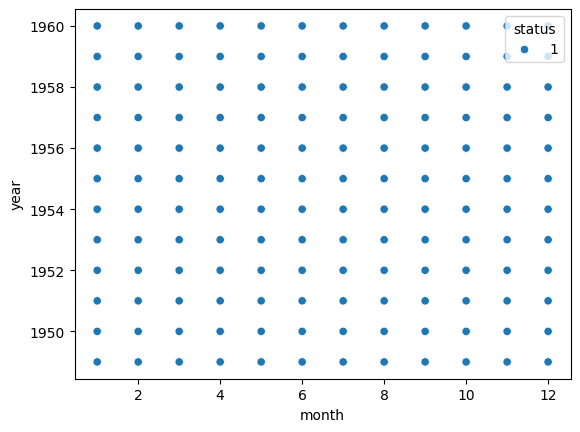

In [60]:
csv_data["status"] = csv_data['n_passengers'].apply(lambda x: 1 if x>0 and x is not None else 0)
csv_data["month"]  = csv_data['date'].apply(lambda x: x.split('-')[1]).astype(int)
csv_data["year"]   = csv_data['date'].apply(lambda x: x.split('-')[0]).astype(int)
heat_dt = pd.DataFrame(csv_data, columns=['status','month','year']).set_index(['month','year'])
heat_dt
sns.scatterplot(heat_dt, x='month', y='year', hue='status')

<Axes: xlabel='year', ylabel='month'>

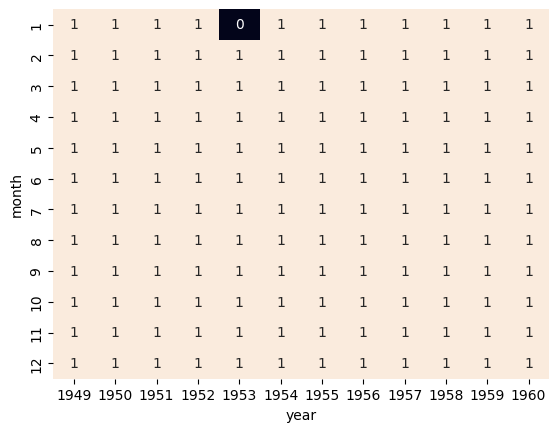

In [67]:
csv_data["status"] = csv_data['n_passengers'].apply(lambda x: 1 if x>0 and x is not None else 0)
csv_data["month"]  = csv_data['date'].apply(lambda x: x.split('-')[1]).astype(int)
csv_data["year"]   = csv_data['date'].apply(lambda x: x.split('-')[0]).astype(int)
heat_dt = pd.DataFrame(csv_data, columns=['status','month','year']).set_index(['month','year'])
heat_dt2 = heat_dt.pivot_table(index='month', columns='year', values='status')
heat_dt2.iloc[0,4] = 0
sns.heatmap(heat_dt2, annot=True, cbar=False)

TypeError: Image data of dtype object cannot be converted to float

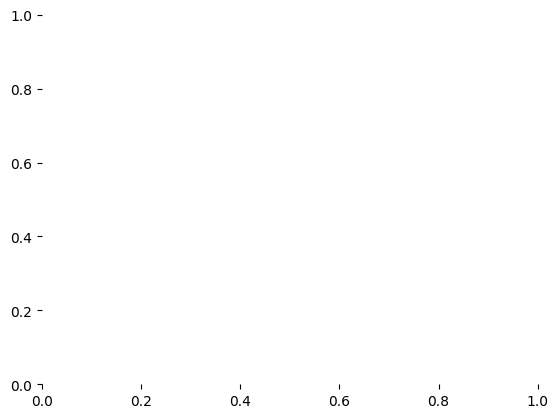

In [33]:
sns.heatmap(csv_data[['month','year','status']], annot=True)